# 11l — Barahhou tracking-error decomposition

The final analyses in this chapter's net-zero toolkit, named after
Barahhou (a co-author on the underlying research): further explorations
of the tracking-error/decarbonization framework built across the
preceding sections, organized into 4 reusable patterns:

1. Risk (bps) vs. time, CTB-vs-PAB, 2x2 scope grid.
2. The same grid with a shaded gap between two named scenarios
   ("Decarbonization" vs. "Transition") plus a printed average gap over
   2022-2030.
3. Sector-level radar ("spider") charts comparing carbon intensity
   across selected years/scenarios, one axis per GICS sector.
4. A risk metric fit as a function of CI-reduction level directly, then
   evaluated along the CTB/PAB glide paths (rather than fit against
   time, like the first pattern above).

All of these are built from real data available alongside this
notebook.


In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


def packr(x, y):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    return x[mask], y[mask]


def smoothing_spline_curve(x_fit, y_fit, x_grid, p, scale=1.0, s=None, s_scale=0.1):
    # Fits a smoothing spline through (x_fit, y_fit) and evaluates it on
    # x_grid, masking beyond the fitted range. Uses scipy's
    # UnivariateSpline (in place of the third-party csaps package used
    # in 11f/11g/11i). csaps's `p` (its `smooth` argument, in [0, 1]
    # with 1 = pure interpolation) and UnivariateSpline's `s` follow
    # roughly inverse conventions (p -> 1 corresponds to s -> 0), so
    # unless an explicit `s` is supplied we derive one from `p` and the
    # data being fitted: s = s_scale * n * var(y_fit) * (1 - p). This
    # keeps p=1 exactly interpolating (s=0) and scales the smoothing
    # target with each series' own variance, so callers can keep
    # passing the same p values used with csaps.
    x_fit, y_fit = packr(x_fit, y_fit)
    x_grid = np.asarray(x_grid, dtype=float)
    if s is None:
        s = max(s_scale * len(x_fit) * np.var(y_fit) * (1 - p), 0.0)
    spline = UnivariateSpline(x_fit, y_fit, k=3, s=s)
    y = scale * spline(x_grid)
    return np.where(x_grid > x_fit[-1], np.nan, y)


SCOPE_TITLES = [r"$\mathcal{SC}_1$", r"$\mathcal{SC}_{1-2}$",
                r"$\mathcal{SC}^{up}_{1-3}$", r"$\mathcal{SC}_{1-3}$"]

## 1. Tracking error vs. time, CTB vs. PAB

Two independent universes (differing only in the shipped `sigma_w`
data), each showing the tracking-error-volatility glide path under the
CTB and PAB benchmarks side by side, across the 4 emission scopes.


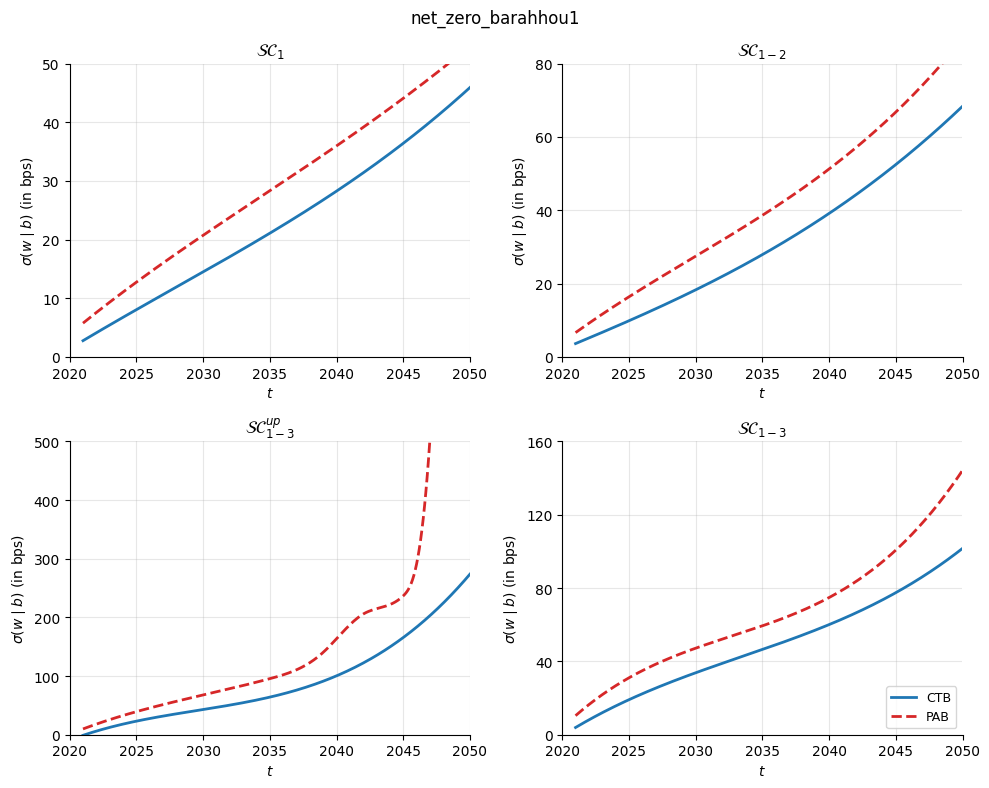

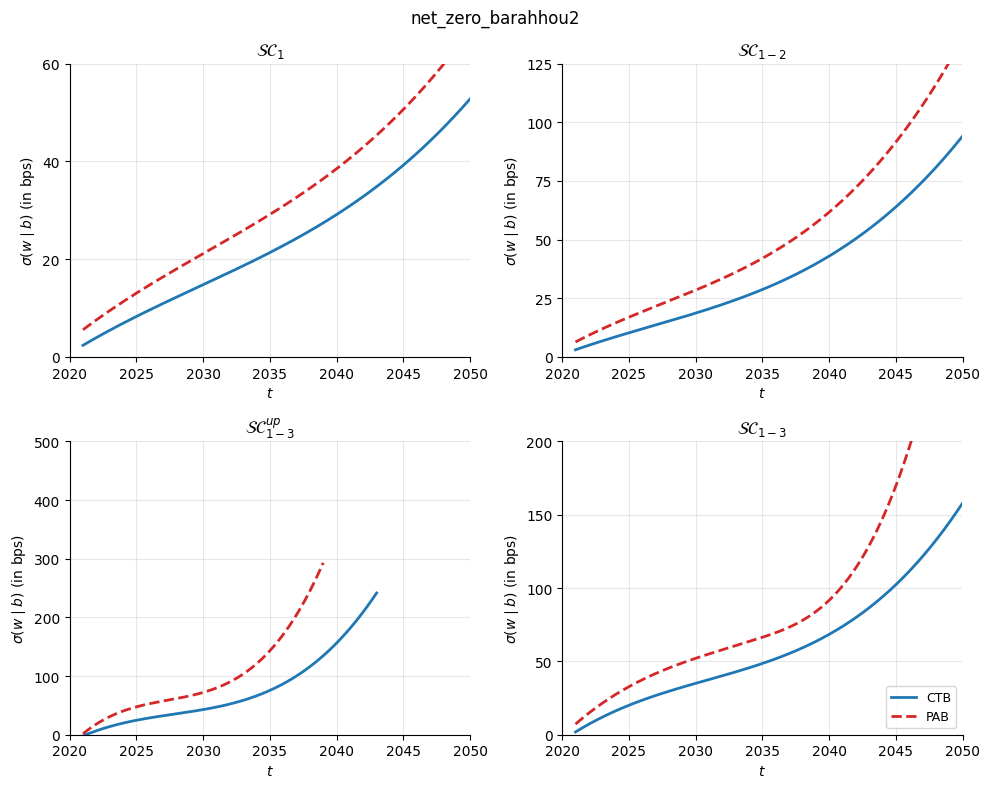

In [2]:
def plot_barahhou_te(mat_name, ylims, yticks_step, title):
    mat = sio.loadmat(f"{DATA_DIR}/{mat_name}.mat")
    t_data = mat["t"].ravel().astype(float)
    sigma_w = mat["sigma_w"]  # (nT, 8) = 4 scopes x [CTB, PAB]

    x_grid = np.arange(2021, 2050 + 1e-9, 0.1)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for scope, ax in enumerate(axes.flat):
        data = sigma_w[:, 2 * scope:2 * scope + 2]
        y_ctb = smoothing_spline_curve(t_data, data[:, 0], x_grid, p=0.9, scale=1e4)
        y_pab = smoothing_spline_curve(t_data, data[:, 1], x_grid, p=0.9, scale=1e4)
        ax.plot(x_grid, y_ctb, "-", color="tab:blue", lw=2, label="CTB")
        ax.plot(x_grid, y_pab, "--", color="tab:red", lw=2, label="PAB")
        ax.set_xlim(2020, 2050)
        ax.set_ylim(*ylims[scope])
        ax.set_yticks(np.arange(0, ylims[scope][1] + 1e-9, yticks_step[scope]))
        ax.set_title(SCOPE_TITLES[scope])
        ax.set_xlabel("$t$")
        ax.set_ylabel(r"$\sigma(w\mid b)$ (in bps)")
        ax.grid(True, alpha=0.3)
    axes.flat[-1].legend(fontsize=9, loc="lower right")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_barahhou_te("chap11_net_zero_Barahhou1", ylims=[(0, 50), (0, 80), (0, 500), (0, 160)],
                  yticks_step=[10, 20, 100, 40], title="net_zero_barahhou1")
plot_barahhou_te("chap11_net_zero_Barahhou2", ylims=[(0, 60), (0, 125), (0, 500), (0, 200)],
                  yticks_step=[20, 25, 100, 50], title="net_zero_barahhou2")

## 2. Tracking error vs. time with shaded scenario gap

Same 2x2 grid, now comparing "Decarbonization" vs. "Transition"
scenarios with the region between them shaded, plus the average gap
between the two curves over 2022-2030 printed per scope.


net_zero_barahhou3, $\mathcal{SC}_1$: mean(Transition - Decarbonization), 2022-2030 = 24.1966 bps
net_zero_barahhou3, $\mathcal{SC}_{1-2}$: mean(Transition - Decarbonization), 2022-2030 = 22.9612 bps
net_zero_barahhou3, $\mathcal{SC}^{up}_{1-3}$: mean(Transition - Decarbonization), 2022-2030 = 17.3881 bps
net_zero_barahhou3, $\mathcal{SC}_{1-3}$: mean(Transition - Decarbonization), 2022-2030 = 15.3740 bps


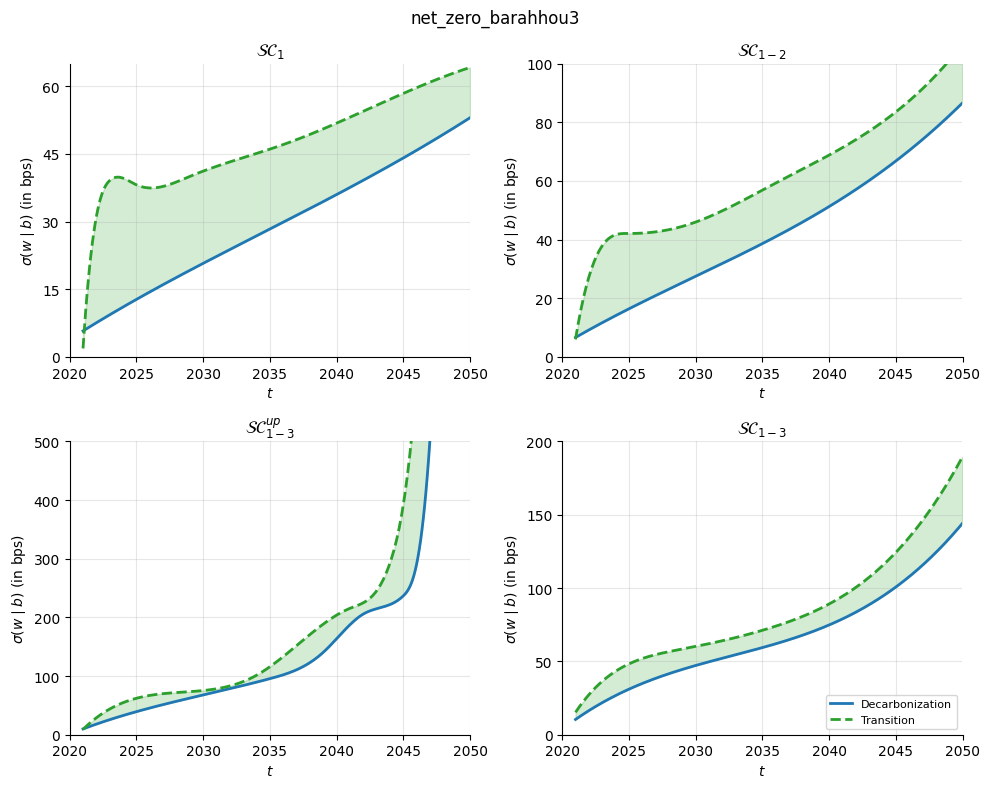

net_zero_barahhou4, $\mathcal{SC}_1$: mean(Transition - Decarbonization), 2022-2030 = 27.6535 bps
net_zero_barahhou4, $\mathcal{SC}_{1-2}$: mean(Transition - Decarbonization), 2022-2030 = 25.3054 bps
net_zero_barahhou4, $\mathcal{SC}^{up}_{1-3}$: mean(Transition - Decarbonization), 2022-2030 = 19.7434 bps
net_zero_barahhou4, $\mathcal{SC}_{1-3}$: mean(Transition - Decarbonization), 2022-2030 = 17.5252 bps


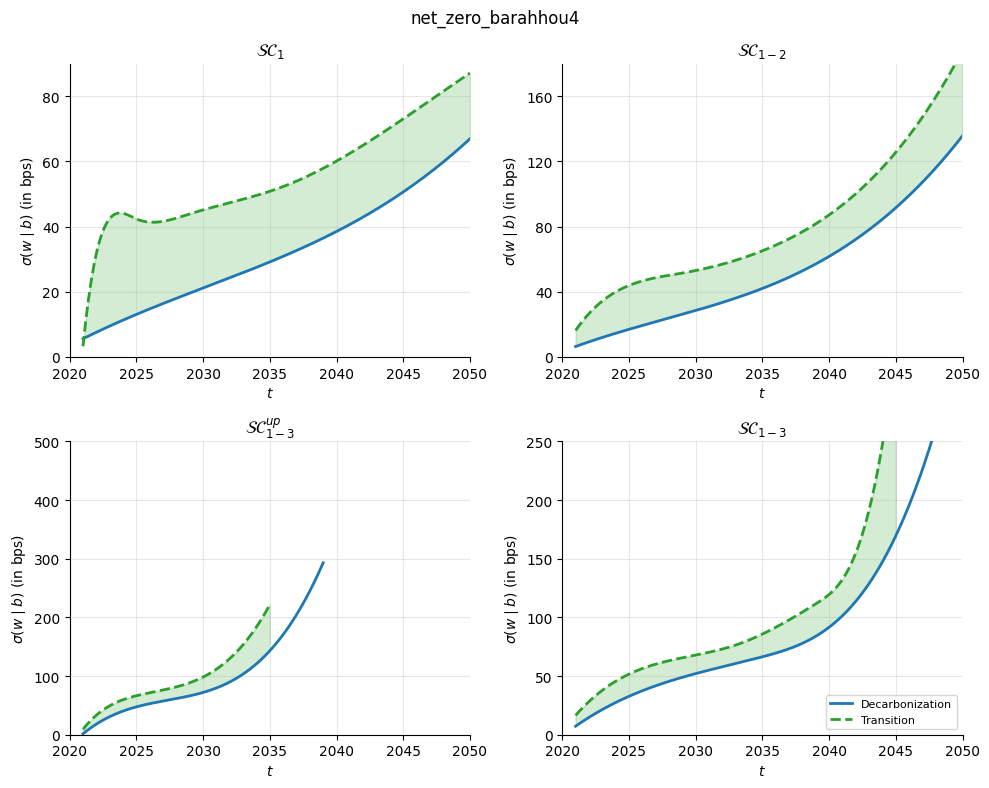

net_zero_barahhou5, $\mathcal{SC}_1$: mean(Transition - Decarbonization), 2022-2030 = 46.4397 bps
net_zero_barahhou5, $\mathcal{SC}_{1-2}$: mean(Transition - Decarbonization), 2022-2030 = 41.2269 bps
net_zero_barahhou5, $\mathcal{SC}^{up}_{1-3}$: mean(Transition - Decarbonization), 2022-2030 = 30.2797 bps
net_zero_barahhou5, $\mathcal{SC}_{1-3}$: mean(Transition - Decarbonization), 2022-2030 = 40.6322 bps


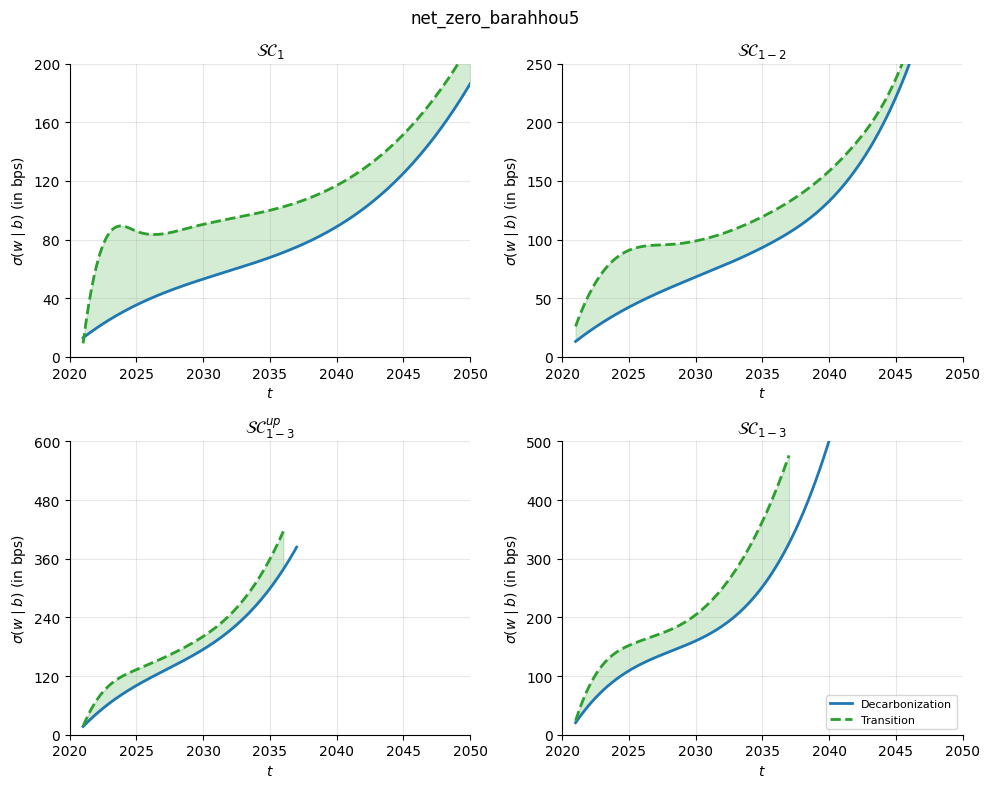

net_zero_barahhou6, $\mathcal{SC}_1$: mean(Transition - Decarbonization), 2022-2030 = 75.1198 bps
net_zero_barahhou6, $\mathcal{SC}_{1-2}$: mean(Transition - Decarbonization), 2022-2030 = 78.6046 bps
net_zero_barahhou6, $\mathcal{SC}^{up}_{1-3}$: mean(Transition - Decarbonization), 2022-2030 = 69.9107 bps
net_zero_barahhou6, $\mathcal{SC}_{1-3}$: mean(Transition - Decarbonization), 2022-2030 = 50.5048 bps


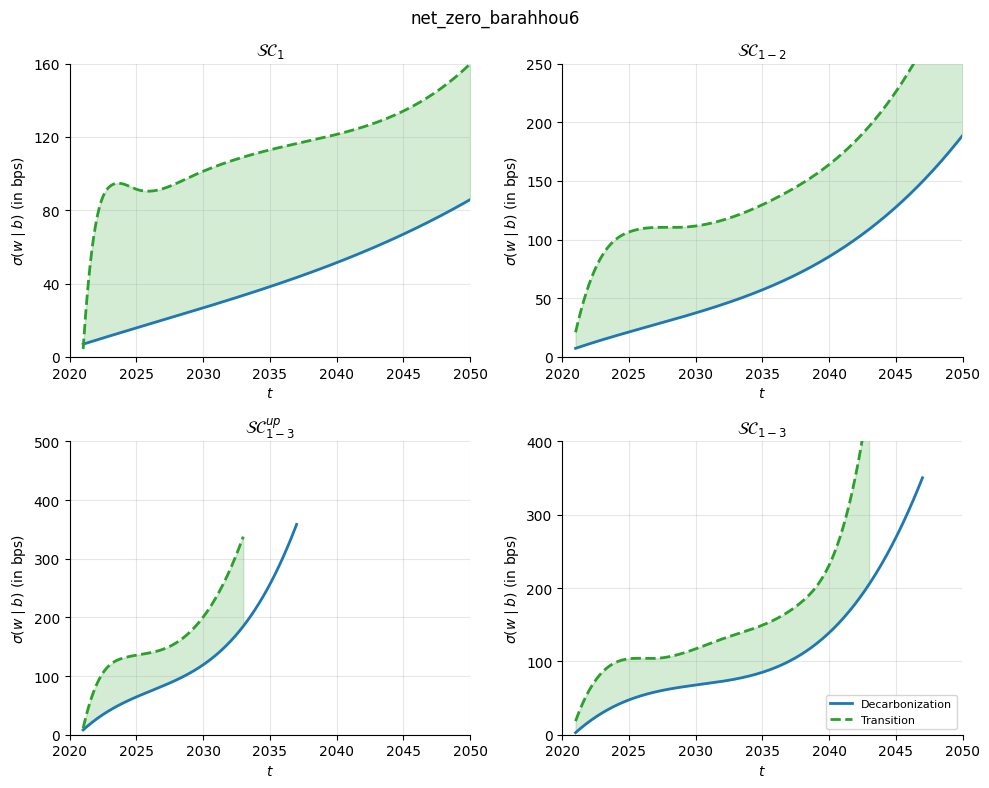

In [3]:
def plot_barahhou_gap(mat_name, ylims, yticks_step, title):
    mat = sio.loadmat(f"{DATA_DIR}/{mat_name}.mat")
    t_data = mat["t"].ravel().astype(float)
    sigma_w = mat["sigma_w"]

    x_grid = np.arange(2021, 2050 + 1e-9, 0.1)
    window = (x_grid >= 2022) & (x_grid <= 2030)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for scope, ax in enumerate(axes.flat):
        data = sigma_w[:, 2 * scope:2 * scope + 2]
        y1 = smoothing_spline_curve(t_data, data[:, 0], x_grid, p=0.9, scale=1e4)
        y2 = smoothing_spline_curve(t_data, data[:, 1], x_grid, p=0.9, scale=1e4)
        ax.plot(x_grid, y1, "-", color="tab:blue", lw=2, label="Decarbonization")
        ax.plot(x_grid, y2, "--", color="tab:green", lw=2, label="Transition")
        valid = ~np.isnan(y1) & ~np.isnan(y2)
        ax.fill_between(x_grid[valid], y1[valid], y2[valid], color="tab:green", alpha=0.2)
        ax.set_xlim(2020, 2050)
        ax.set_ylim(*ylims[scope])
        ax.set_yticks(np.arange(0, ylims[scope][1] + 1e-9, yticks_step[scope]))
        ax.set_title(SCOPE_TITLES[scope])
        ax.set_xlabel("$t$")
        ax.set_ylabel(r"$\sigma(w\mid b)$ (in bps)")
        ax.grid(True, alpha=0.3)
        gap = np.nanmean((y2 - y1)[window])
        print(f"{title}, {SCOPE_TITLES[scope]}: mean(Transition - Decarbonization), 2022-2030 = {gap:.4f} bps")
    axes.flat[-1].legend(fontsize=8, loc="lower right")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


barahhou36_config = [
    ("chap11_net_zero_Barahhou3", [(0, 65), (0, 100), (0, 500), (0, 200)], [15, 20, 100, 50]),
    ("chap11_net_zero_Barahhou4", [(0, 90), (0, 180), (0, 500), (0, 250)], [20, 40, 100, 50]),
    ("chap11_net_zero_Barahhou5", [(0, 200), (0, 250), (0, 600), (0, 500)], [40, 50, 120, 100]),
    ("chap11_net_zero_Barahhou6", [(0, 160), (0, 250), (0, 500), (0, 400)], [40, 50, 100, 100]),
]
for mat_name, ylims, yticks_step in barahhou36_config:
    plot_barahhou_gap(mat_name, ylims, yticks_step, mat_name.replace("chap11_net_zero_B", "net_zero_b"))

## 3. Sector-level carbon-intensity radar charts

A custom `spider_plot` function is implemented directly with
matplotlib: each of the 11 GICS sectors is its own axis, individually
normalized to its own maximum value across the plotted series -- the
reason a plain `matplotlib` polar plot won't do on its own, since polar
axes share one radial scale, so each axis needs its own independent
normalization. Label positions get a small hand-tuned per-sector offset
(`LABEL_DELTA`) to keep the 11 sector names from overlapping the plot.


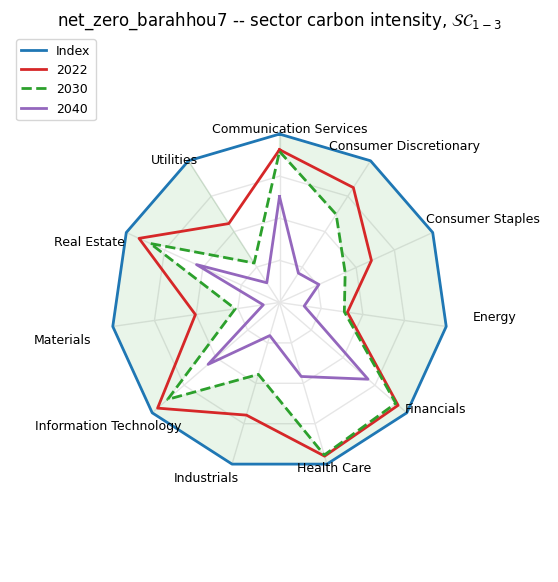

In [4]:
LABEL_DELTA = np.array([
    [0.30, -0.60, 0.00], [0.60, -0.20, 0.00], [0.80, 0.10, 0.00], [0.70, 0.40, 0.00],
    [0.30, 0.60, 0.00], [0.00, 0.60, 0.00], [-0.55, 0.30, 0.00], [-0.75, 0.10, 0.00],
    [-0.75, -0.30, 0.00], [-0.40, -0.60, 0.00], [0.00, -0.60, 0.00],
]) / 5.0


def read_barahhou_sector_block(xlsx_path, sheet, scope):
    raw = pd.read_excel(xlsx_path, sheet_name=sheet, header=None)
    years = raw.iloc[0, 2:32].astype(float).values
    sector_names = raw.iloc[1:12, 1].values
    n_sector = len(sector_names)
    row0 = 1 + (scope - 1) * n_sector
    data = raw.iloc[row0:row0 + n_sector, 2:32].astype(float).values  # (n_sector, n_years)
    return years, sector_names, data


def spider_plot(ax, data, ax_max, labels, colors, linestyles, shaded_idx=None, shaded_color=None):
    n_sector = data.shape[1]
    angles = np.pi / 2 - 2 * np.pi * np.arange(n_sector) / n_sector

    for r in (0.25, 0.5, 0.75, 1.0):
        xs, ys = r * np.cos(angles), r * np.sin(angles)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]), color=(0.9, 0.9, 0.9), lw=1, zorder=1)
    for a in angles:
        ax.plot([0, np.cos(a)], [0, np.sin(a)], color=(0.9, 0.9, 0.9), lw=1, zorder=1)

    norm = data / ax_max[None, :]
    if shaded_idx is not None:
        i0, i1 = shaded_idx
        xs = np.concatenate([norm[i0] * np.cos(angles), (norm[i1] * np.cos(angles))[::-1]])
        ys = np.concatenate([norm[i0] * np.sin(angles), (norm[i1] * np.sin(angles))[::-1]])
        ax.fill(xs, ys, color=shaded_color, alpha=0.1, zorder=2)

    for k in range(data.shape[0]):
        xs, ys = norm[k] * np.cos(angles), norm[k] * np.sin(angles)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]), linestyles[k], color=colors[k], lw=2, zorder=3)

    for i, a in enumerate(angles):
        x, y = 1.15 * np.cos(a) + LABEL_DELTA[i, 0], 1.15 * np.sin(a) + LABEL_DELTA[i, 1]
        ax.text(x, y, labels[i], ha="center", va="center", fontsize=9)

    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    ax.set_aspect("equal")
    ax.axis("off")


xlsx7 = f"{DATA_DIR}/chap11_net_zero_barahhou7.xlsx"
years, sector_names, data7 = read_barahhou_sector_block(xlsx7, "C3(0,10,2) G=1 CM=-5", scope=4)
selected_years = np.array([2021, 2022, 2030, 2040])
indx_years = pd.Index(years).get_indexer(selected_years)
cnd = indx_years == -1
if cnd.any():
    selected_years = selected_years.copy()
    selected_years[cnd] = years[-1]
    indx_years = pd.Index(years).get_indexer(selected_years)
data7_sel = data7[:, indx_years.astype(int)].T  # (n_series, n_sector)

cnd_eq = data7_sel[-1] == data7_sel[0]
data7_sel[-1, cnd_eq] = data7_sel[-1, cnd_eq] - 1
ax_max7 = data7_sel.max(axis=0)

fig, ax = plt.subplots(figsize=(7, 7))
spider_plot(ax, data7_sel, ax_max7, sector_names,
            colors=["tab:blue", "tab:red", "tab:green", "tab:purple"],
            linestyles=["-", "-", "--", "-"],
            shaded_idx=(0, 2), shaded_color="tab:green")
legend_labels = ["Index"] + [str(int(y)) for y in selected_years[1:]]
ax.legend(handles=[plt.Line2D([0], [0], color=c, ls=ls, lw=2) for c, ls in
                    zip(["tab:blue", "tab:red", "tab:green", "tab:purple"], ["-", "-", "--", "-"])],
          labels=legend_labels, fontsize=9, loc="upper left")
ax.set_title("net_zero_barahhou7 -- sector carbon intensity, $\\mathcal{SC}_{1-3}$")
plt.show()

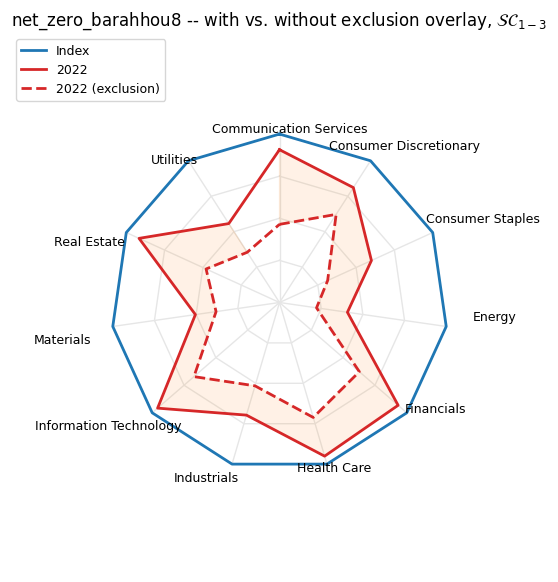

In [5]:
years1, sector_names, data1_full = read_barahhou_sector_block(xlsx7, "C3(0,10,2) G=1 CM=-5", scope=4)
selected_year1 = np.array([2021, 2022])
indx1 = pd.Index(years1).get_indexer(selected_year1)
assert (indx1 != -1).all(), "selected_year1 not found in years1"
data1 = data1_full[:, indx1].T

years2, _, data2_full = read_barahhou_sector_block(xlsx7, "C3 G=1 CM=-5 Exclusion", scope=4)
selected_year2 = np.array([2022])
indx2 = pd.Index(years2).get_indexer(selected_year2)
assert (indx2 != -1).all(), "selected_year2 not found in years2"
data2 = data2_full[:, indx2].T

data8_sel = np.vstack([data1, data2])
cnd_eq = data8_sel[-1] == data8_sel[0]
data8_sel[-1, cnd_eq] = data8_sel[-1, cnd_eq] - 1
ax_max8 = data8_sel.max(axis=0)

fig, ax = plt.subplots(figsize=(7, 7))
spider_plot(ax, data8_sel, ax_max8, sector_names,
            colors=["tab:blue", "tab:red", "tab:red"],
            linestyles=["-", "-", "--"],
            shaded_idx=(1, 2), shaded_color="tab:orange")
legend_labels = ["Index", "2022", "2022 (exclusion)"]
ax.legend(handles=[plt.Line2D([0], [0], color=c, ls=ls, lw=2) for c, ls in
                    zip(["tab:blue", "tab:red", "tab:red"], ["-", "-", "--"])],
          labels=legend_labels, fontsize=9, loc="upper left")
ax.set_title("net_zero_barahhou8 -- with vs. without exclusion overlay, $\\mathcal{SC}_{1-3}$")
plt.show()

## 4. Risk vs. reduction level, evaluated along the CTB/PAB glide path

Unlike patterns 1-2 (which fit risk directly against time), these two
analyses fit a risk metric as a function of the **CI-reduction level**
$R$ itself, then evaluate that fit at the $R(t)$ values the CTB and PAB
glide paths imply -- turning a risk-vs-reduction curve into a
risk-vs-time curve via a change of variable.


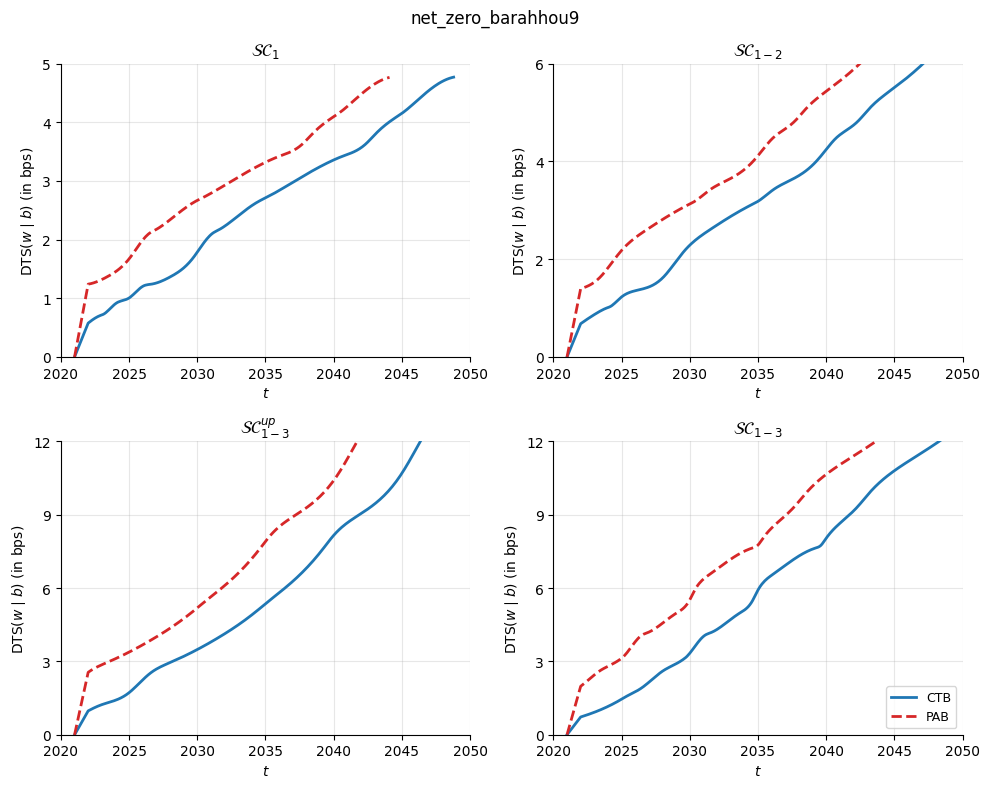

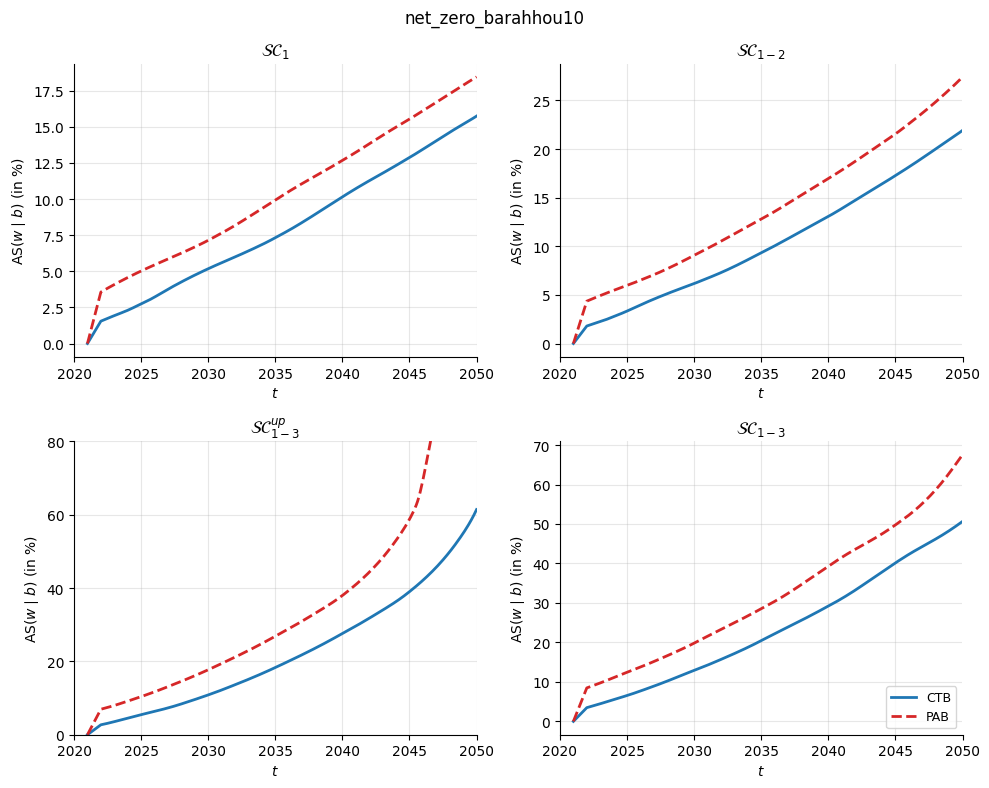

In [6]:
def plot_barahhou_glide(xlsx_name, ylims, yticks_step, tol, ylabel, scale, x_cutoff, title):
    df = pd.read_excel(f"{DATA_DIR}/{xlsx_name}.xlsx", sheet_name="Sheet1")
    data_R = df.iloc[:, 0].values / 100.0
    data_Risk = df.iloc[:, 1:5].values / (100.0 if scale == 1e2 else 1.0)

    t0 = 2021
    t = np.concatenate([[2021], np.arange(2022, 2050 + 1e-9, 0.1)])
    R_CTB = 1 - (1 - 0.30) * (1 - 0.07) ** (t - t0 - 1)
    R_PAB = 1 - (1 - 0.50) * (1 - 0.07) ** (t - t0 - 1)
    R_CTB[0], R_PAB[0] = 0.0, 0.0

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for scope, ax in enumerate(axes.flat):
        x_fit, y_fit = data_R, data_Risk[:, scope]
        if x_cutoff is not None:
            m = x_fit <= x_cutoff
            x_fit, y_fit = x_fit[m], y_fit[m]
        y_ctb = smoothing_spline_curve(x_fit, y_fit, R_CTB, p=1 - tol, scale=scale)
        y_pab = smoothing_spline_curve(x_fit, y_fit, R_PAB, p=1 - tol, scale=scale)
        ax.plot(t, y_ctb, "-", color="tab:blue", lw=2, label="CTB")
        ax.plot(t, y_pab, "--", color="tab:red", lw=2, label="PAB")
        ax.set_xlim(2020, 2050)
        if ylims[scope] is not None:
            ax.set_ylim(*ylims[scope])
            ax.set_yticks(np.arange(0, ylims[scope][1] + 1e-9, yticks_step[scope]))
        ax.set_title(SCOPE_TITLES[scope])
        ax.set_xlabel("$t$")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
    axes.flat[-1].legend(fontsize=9, loc="lower right")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_barahhou_glide("chap11_net_zero_barahhou9",
                     ylims=[(0, 5), (0, 6), (0, 12), (0, 12)], yticks_step=[1, 2, 3, 3],
                     tol=1e-4, ylabel=r"$\mathrm{DTS}(w\mid b)$ (in bps)", scale=1.0, x_cutoff=0.90,
                     title="net_zero_barahhou9")
plot_barahhou_glide("chap11_net_zero_barahhou10",
                     ylims=[None, None, (0, 80), None], yticks_step=[None, None, 20, None],
                     tol=0.0, ylabel=r"$\mathrm{AS}(w\mid b)$ (in %)", scale=1e2, x_cutoff=None,
                     title="net_zero_barahhou10")

## Chapter 11 wrap-up

This closes out Chapter 11's net-zero and decarbonization toolkit: from
the equity/bond tracking-error optimizations and carbon-budget worked
examples early in the chapter, through stock-level results, taxonomy
and thematic instruments, core-satellite allocation, and this notebook's
further explorations of the same framework. One stock-level compute
step earlier in the chapter (`11i`) could not be reproduced there
because its required holdings/emissions dataset isn't available, though
the related precomputed plots are still built from what data does
exist.
